![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

Wylosowano małą próbę, dla której można określić przedziały ufności zgodnie z klasyczną teorią statsytyki - w oparciu o rozkład T-Studenta. Dla porównania wykorzystano metody bootstrapowe określania przedziałów ufności - wyniki powinny być podobne. 
Jest to postępowanie podobne do porównania rozwiązań przybliżonych (Bootstrapping) z rozwiązaniem dokładnym (T-Student CI)

In [1]:
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from scipy.optimize import newton_krylov # do numerycznego rozwiązania algebraicznego równania nieliniowego

**Wylosowanie próby o liczności 20 elementów z rozkładu normalnego o średniej 5 i odchyleniu standardowym 2**

In [2]:
NormalDistribution = st.norm(5,2)
X = np.round(NormalDistribution.rvs(20),2)
print(X)

[4.19 4.17 7.9  6.7  4.16 6.85 5.71 4.16 7.4  4.6  4.84 1.07 3.93 5.22
 8.85 2.74 9.62 4.69 7.16 4.23]


**Obliczenie przedziałow ufności z wykorzystaniem rozkładu T-Studenta**

Jako, ze wszystkie założenia są spełnione można wykorzystać ten model statystyki klasycznej, a wyniki wykorzystac do porównania z wynikami otrzymanymi za pomocą metod typu bootstrap.

In [3]:
a = 0.05
n = len(X)
df = n-1
StudentTDistribution = st.t(df)
m = st.tmean(X)
s = st.tstd(X)
ta = StudentTDistribution.ppf(1-a/2)
print("Przedziały ufności wyznaczone z użyciem rozkładu T-Studenta (rozwiązanie dokładne)")
print((m-s*ta/n**0.5, m+s*ta/n**0.5))

Przedziały ufności wyznaczone z użyciem rozkładu T-Studenta (rozwiązanie dokładne)
(4.426365437643789, 6.3926345623562115)


**Bootstrapping**

Przeprowadzenie K losowań z powtórzeniami z wcześniej otrzymanej próby, a następnie obliczenie średniej z każdej otrzymanej próby bootstrappowej.

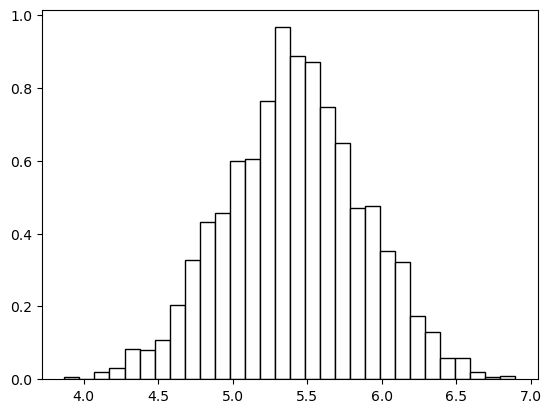

In [4]:
K = 2000 #liczba prób bootstrap: tzw. resampling
M = np.zeros(K) # utworzenie wektora zawierajacego badany parametr (tu średnią) z każdej próby typu bootstrap

for k in range(K):
    M[k] = st.tmean(np.random.choice(X,n)) #wybierz z próby próbę bootstrapową, 
                                           #czyli próbe o takiej samej liczności z powtórzeniami
    
plt.hist(M,bins=30,density=True,color="white",edgecolor="black")
pass

#### Wykorzystanie modelu przedziału ufności typu bootstrap dla dowolnych rozkładów

Najprostszym sposobem określenia przedziałów ufności jest określenie odpowiednich kwantyli z wygenerowanych wartości badanej statystyki. Np.:

In [5]:
np.quantile(M,[a/2,1-a/2])

array([4.5038375, 6.326075 ])

**Wykorzystanie modelu przedziału ufności typu bootstrap dla rozkładów z rodziny normalnych**

Jest to model odrobinę dokładniejszy niż model przedstawiony powyżej, który nie wymaga spełnienia żadnych założeń.

In [6]:
StdND = st.norm(0,1) #standardized normal distribution
m1 = np.mean(M)
SE = ((1/(K-1))*np.sum( (m1-M)**2))**0.5
bCI = np.array( (m + StdND.ppf(a/2)*SE, m + StdND.ppf(1-a/2)*SE) )
print("Bootstrappowe przedziały ufności [metoda zakładająca, że rozkład parametru jest normalny lub zbliżony]")
print(bCI)

Bootstrappowe przedziały ufności [metoda zakładająca, że rozkład parametru jest normalny lub zbliżony]
[4.50281483 6.31618517]
